In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

In [4]:
df = pd.read_csv('homeprices-MLR(homeprices).csv')
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18_,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,3600,3.0,30,595000
6,4100..,6.0,8,810000


In [5]:
df['area'] = df['area'].apply(lambda x: str(x).replace('.' , ''))
df['age'] = df['age'].str.replace('_' , '')
df['bedrooms'] = df['bedrooms'].apply(lambda x: str(x))
df = df.drop_duplicates()
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,nan,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
6,4100,6.0,8,810000


In [6]:
for x in df.index:
  if df.loc[x, 'bedrooms'] == 'nan':
    df.drop(x, inplace = True)
df = df.reset_index(drop = True)
df


/tmp/ipykernel_10106/2576274772.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(x, inplace = True)


,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3600,3.0,30,595000
3,4000,5.0,8,760000
4,4100,6.0,8,810000


In [7]:
# Multi/Linear Regression
reg = linear_model.LinearRegression()
reg = reg.fit(df[['area' , 'bedrooms' , 'age']] , df['price'])
reg

LinearRegression()

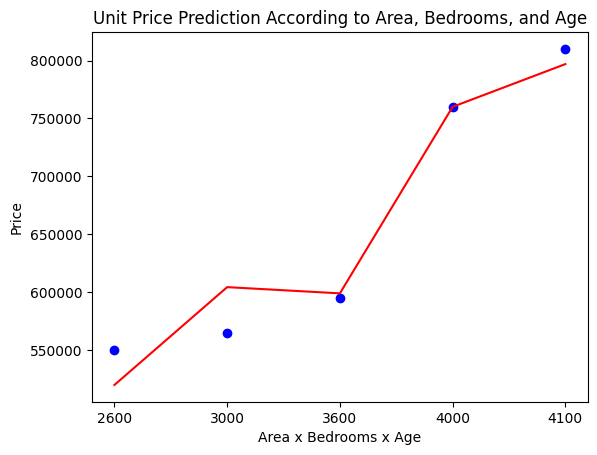

In [8]:
# Visualization
plt.title('Unit Price Prediction According to Area, Bedrooms, and Age')
plt.xlabel('Area x Bedrooms x Age')
plt.ylabel('Price')
plt.scatter(df['area'] , df['price'] , color = 'blue' , marker = 'o')
plt.plot(df['area'] , reg.predict(df[['area' , 'bedrooms' , 'age' ]]), color = 'red')
plt.show()

In [13]:
a = int(input('Enter area: '))
b = int(input('Enter Bedrooms: '))
c = int(input('Enter Age: '))

pred = reg.predict([[a , b , c]])
print('Predicted Price: ', float(pred))

Enter area: 2600
Enter Bedrooms: 2
Enter Age: 21
Predicted Price:  490874.51235370635


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/tmp/ipykernel_10106/3204924746.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Predicted Price: ', float(pred))


In [10]:
# m or coefficient
reg.coef_

array([  108.83858908, 26014.7106632 , -2977.4869961 ])

In [11]:
# b or y intercept
reg.intercept_

np.float64(218391.98634590406)

In [12]:
# formula:
#y = mx + b
# 108.83858908(50) + 26014.7106632(1) + -2977.4869961(20) + 218391.98634590406  = 190298.88654